In [1]:
import numpy as np
import sklearn
import numpy.random as npr
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from scipy.linalg import orth
import time
import os

from sca.models import SCA, WeightedPCA, SCANonlinear
from sca.util import get_sample_weights, get_accuracy

#### Function for plotting

In [2]:
def plot_model_latents(model,h_all,trial_all,active_units,rule_sublist_plot,rule_names_plot,ylim,latent_order,save_dir_and_name=None):

    n_latent = R_est

    fig = plt.figure(figsize=(1.2*len(rule_sublist_plot),.9*n_latent),tight_layout=True,facecolor='white')

    for ri in range(len(rule_sublist_plot)):
        rule = rule_sublist_plot[ri]

        latents=model.transform(h_all['by_rule'].item()[rule][:,:,active_units])

        n_time,n_trial,_ = np.shape(latents)
#         print(np.shape(latents))

        ax = fig.add_subplot(n_latent,len(rule_sublist_plot),ri+1)
        trial_in = trial_all[rule]
#             plt.plot(range(len(trial_in)),trial_in[:,0,0],'s',markersize = 3)
        plt.plot(range(len(trial_in)),trial_in[:,0,0], linewidth = 3)

        for stim_ind in range(2,6):
#                 plt.scatter(range(len(trial_in)),abs(trial_in[:,0,stim_ind])+.05,s = 10,c = np.zeros(len(trial_in)),
#                         cmap = 'hsv',alpha = .5,marker = 's')
            non_zero_inds = abs(trial_in[:,0,stim_ind])>min(abs(trial_in[:,0,stim_ind]))
            for z in range(len(non_zero_inds)):
                if non_zero_inds[z]:
                    plt.scatter(z,non_zero_inds[z]+.05,s=10,c=0,
                               cmap='hsv',alpha=.5,marker='s')

        plt.plot(range(len(trial_in)),trial_in[:,0,4:]+.1,linewidth = 3)

        plt.ylim([.99, 1.2])

        ax.set_xticks([])
        if ri==0:
            ax.set_yticks([1,1.05,1.1])
            ax.set_yticklabels(['Fixation','Stimulus','Context'],fontsize = 9)
        else:
            ax.set_yticks([])

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        plt.title(rule_names_plot[ri],fontsize = 9, y=1.0, pad=-8)

        subplot_counter = 0
        latent_set = range(1,n_latent+1)
        n_vis_latents = len(latent_set)


        for x in latent_set:

            subplot_counter +=1

            ax = fig.add_subplot(n_latent+1,len(rule_sublist_plot),subplot_counter*len(rule_sublist_plot)+ri+1)

            colors = plt.cm.hsv(np.linspace(0, 1, n_trial))

            for ti in range(0,n_trial,int(np.round(n_trial/20))):

                plt.plot(latents[:,ti,latent_order[x-1]], color=colors[ti],alpha = .8,linewidth = 1.1) 

                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_ylim([-ylim,ylim])
                plt.axis('off')
           
        

    if save_dir_and_name is not None:
        plt.savefig(os.path.join(save_dir_and_name+'.pdf'))




### Load Data

In [8]:
#Load directory
load_dir='/Users/.../'

#load task inputs
trial_all = np.load(load_dir+'trial_all.npz',encoding='bytes',allow_pickle=True)

#load network activations (from original network 0)
h_all = np.load(load_dir+'h_all.npz',encoding='bytes',allow_pickle=True)

#### Order of tasks for plotting

In [9]:
#order of tasks
rule_sublist = ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo']

rule_set_names = ['DelayPro', 'ReactPro', 'MemoryPro', 'DelayAnti', 'ReactAnti', 'MemoryAnti',
              'IntegrationModality1', 'IntegrationModality2', 'CtxtIntModality1', 'CtxtIntModality2', 'IntegrationMultimodal',
              'ReactMatch2Sample', 'ReactNonMatch2Sample', 'ReactCategoryPro', 'ReactCategoryAnti']


plot_rule_order=[0,3,2,5,6,7,8,9,10,1,4,13,14,11,12]
plot_rule_list=[rule_sublist[i] for i in plot_rule_order]
plot_rule_names=[rule_set_names[i] for i in plot_rule_order]

print(plot_rule_names)



['DelayPro', 'DelayAnti', 'MemoryPro', 'MemoryAnti', 'IntegrationModality1', 'IntegrationModality2', 'CtxtIntModality1', 'CtxtIntModality2', 'IntegrationMultimodal', 'ReactPro', 'ReactAnti', 'ReactCategoryPro', 'ReactCategoryAnti', 'ReactMatch2Sample', 'ReactNonMatch2Sample']


Using lam_sparse=  0.011943096799478685
Using lam_orthog=  1156.35607488143
Using device cpu


  0%|          | 1/5000 [00:00<14:59,  5.55it/s]

76319.49
580932.6


100%|██████████| 5000/5000 [06:08<00:00, 13.59it/s]


Text(0.5, 1.0, 'Loss over training')

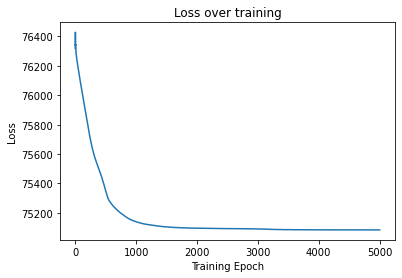

In [10]:
#N latents
R_est=25

#Number of epochs of model fitting
n_epochs=5000

weighted=False
# weighted=True


### Format data for model fitting 


#concatenate activation for each task
#We will be using subsets of trials here to have 20 per task
cat_h_all_by_rule = h_all['by_rule'].item()[rule_sublist[0]][:,0:80:4,:]

for rule in rule_sublist[1:]:
    B = np.shape(h_all['by_rule'].item()[rule])[1]
    cat_h_all_by_rule = np.concatenate((cat_h_all_by_rule,h_all['by_rule'].item()[rule][:,0:B:int(np.round(B/20)),:]),axis = 0)

cat_trials = np.reshape(np.transpose(cat_h_all_by_rule,(1,0,2)),(-1,128))

#currently using all units
active_units = np.argsort(np.var(cat_trials,axis = 0))

X0 = cat_trials[:,active_units]
X=np.copy(X0-np.mean(X0,axis=0)[None,:])



#How much to weight each data point in time
#(this can be helpful for making sure dimensions still aim to explain time points with low activity)
if weighted:
    sample_weights=get_sample_weights(X) #Weight inversely to norm of activity at each time point
else:
    sample_weights=np.ones([X.shape[0],1]) #Weight inversely to norm of activity at each time point


# Fit PCA model
pca = WeightedPCA(n_components=R_est)
pca.fit(X=X,sample_weight = sample_weights)


# Fit SCA model
sca = SCA(n_components=R_est,n_epochs=n_epochs)
sca.fit(X=X,sample_weight = sample_weights)


#Plot the loss over all iterations
plt.figure()
plt.plot(sca.losses)
plt.xlabel('Training Epoch')
plt.ylabel('Loss')
plt.title('Loss over training')


# Plots

In [11]:
latent_order=list(range(25)) #Don't reorder
ylim = 5


### Plot SCA Latents

/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  fig.canvas.print_figure(bytes_io, **kw)


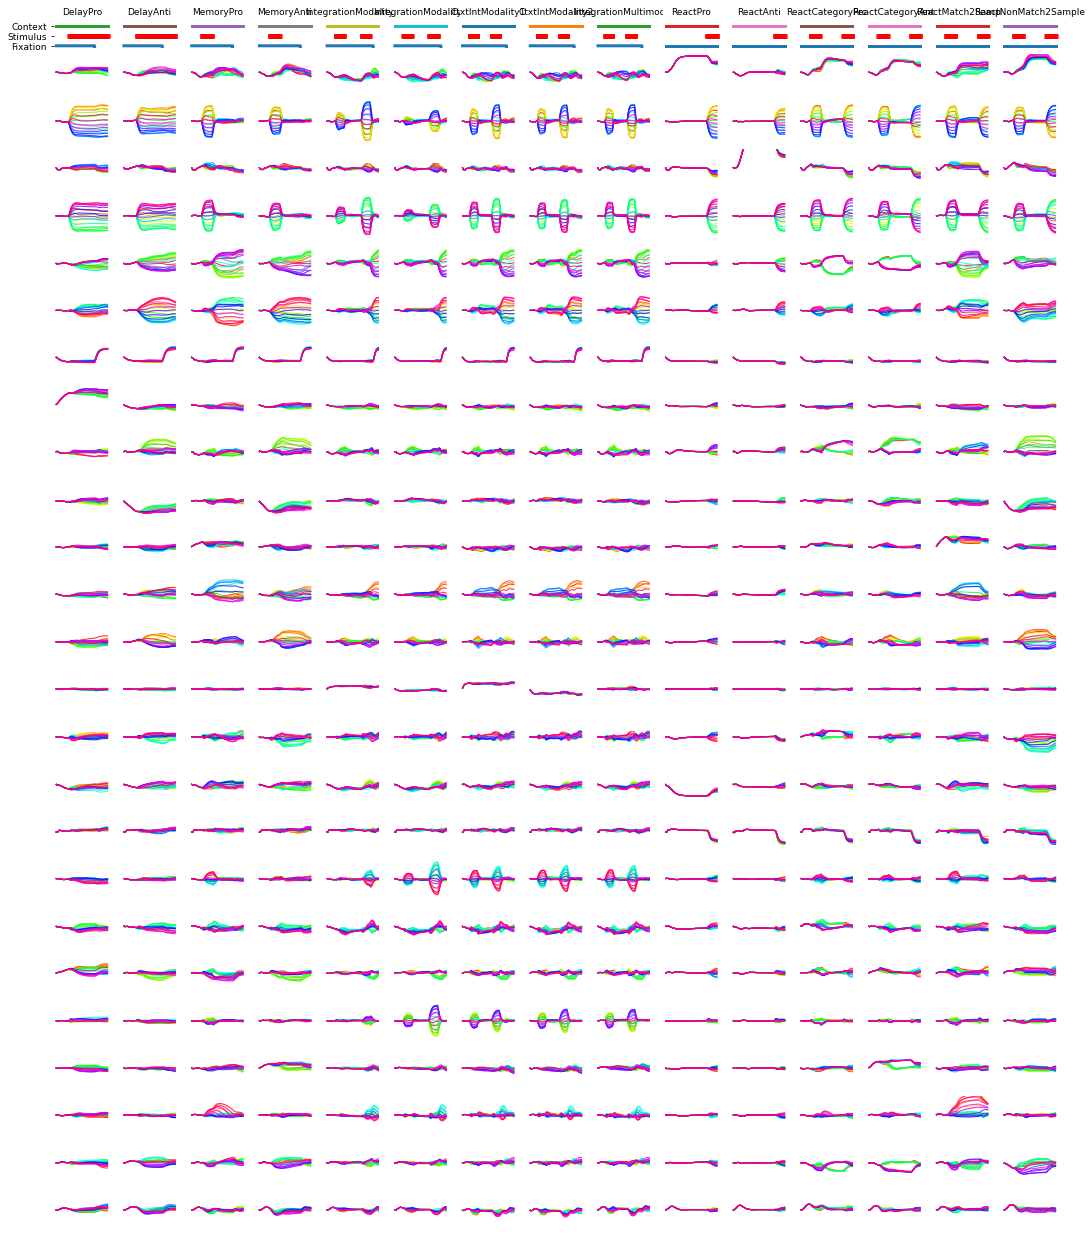

In [7]:
#Plot SCA latents
plot_model_latents(sca,h_all,trial_all,active_units,plot_rule_list,plot_rule_names,ylim,latent_order)

##If you want to save the file
# save_dir_and_name = '/Users/.../sca_latents'
## OR
# save_dir_and_name = './sca_latents'
# plot_model_latents(sca,h_all,trial_all,active_units,plot_rule_list,plot_rule_names,ylim,latent_order,save_dir_and_name)

### Plot PCA Latents

/opt/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  fig.canvas.print_figure(bytes_io, **kw)


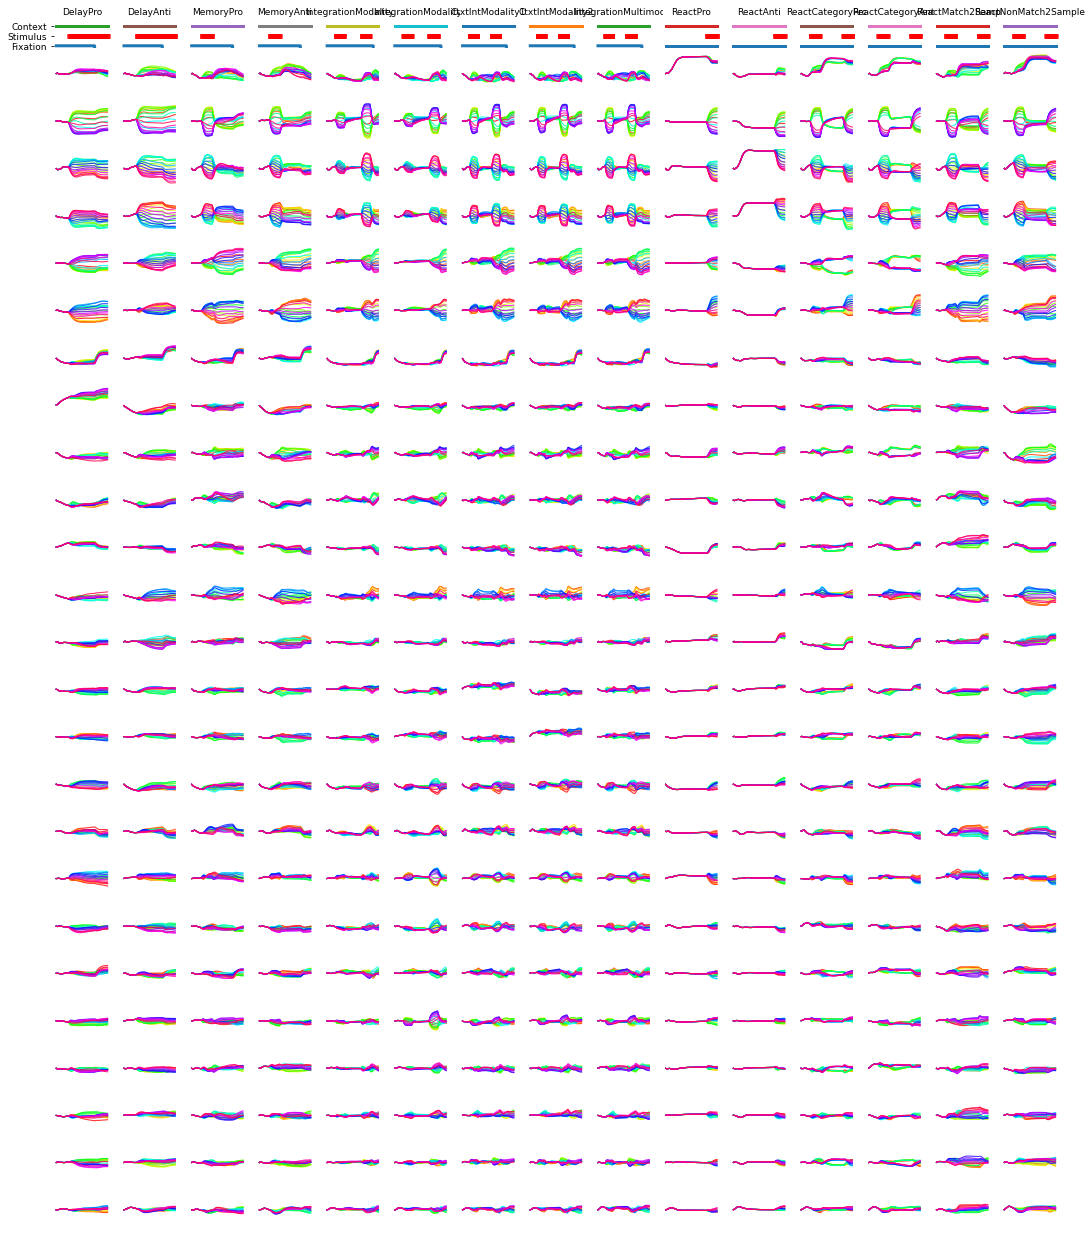

In [13]:
#Plot PCA latents

plot_model_latents(pca,h_all,trial_all,active_units,plot_rule_list,plot_rule_names,ylim,latent_order)

##If you want to save the file
# save_dir_and_name = '/Users/.../pca_latents'
## OR
# save_dir_and_name = './pca_latents'
# plot_model_latents(pca,h_all,trial_all,active_units,plot_rule_list,plot_rule_names,ylim,latent_order,save_dir_and_name)